<a href="https://colab.research.google.com/github/rlaghwo730/BOOSTMAP-2team/blob/master/ttest_ABC_target.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 가설검증: A/B/C군 전체 변수 vs TARGET(연체 여부) — Welch's t-test

**대상 기준**: SK_ID_CURR·TARGET을 제외한 컬럼 중 **수치형(int/float)은 전부 포함**합니다.

**왜 이진 변수까지 t검정에 포함했나**: 원칙적으로 이진(0/1) 변수는 카이제곱이 더 표준적인 기법이지만 이진변수의 평균은 곧 비율이고, 표본이 매우 크면(30만+) t검정과 카이제곱(비율차이 검정) 결과가
수치적으로 거의 수렴. 그래서 하나의 파이프라인으로 전체 변수를 훑어보는 실용적 접근으로
t검정을 그대로 적용했고, 결과표의 `var_type` 컬럼에 "연속형"(정식 t검정) / "이진·범주형(근사)"
(사실상 비율차이 검정에 해당)을 구분 표시해 어디까지가 엄밀한 결과인지 명확히 했습니다.

절차:
1. 수치형 변수 전체 대상 (연속형 + 이진/범주형, 문자열 컬럼은 제외)
2. H0: TARGET=0/1 두 집단의 평균(이진 변수는 비율)이 같다 vs H1: 다르다 (양측검정)
3. Levene's test로 등분산 여부 확인(참고용 — 결과와 무관하게 Welch's 사용)
4. 왜도(skewness) 확인 — 표본이 커서(30만+) CLT로 강건하지만 극단적 왜도는 별도 표시
5. Welch's t-test(equal_var=False) 실행
6. 여러 변수를 한꺼번에 검정하므로 FDR(Benjamini-Hochberg) 보정
7. p-value만이 아니라 효과크기(Cohen's d)도 함께 산출
8. 변수선정_최종.csv(또는 변수선정_재계산.csv)의 IV값과 병합해 최종표 구성

## 0. 환경 설정

In [44]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests

pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 160)

BASE_DIR = "/content/drive/MyDrive/재계산"  # 본인 환경에 맞게 수정

FILES = {
    "A_금융":       os.path.join(BASE_DIR, "model_A_financial_final.csv"),
    "B_기존비금융": os.path.join(BASE_DIR, "model_B_nonfinancial_final.csv"),
    "C_신규비금융": os.path.join(BASE_DIR, "model_C_nonfinancial_new_final.csv"),
}
# IV값이 들어있는 변수선정 파일 — 경로가 다르면 아래 한 줄만 수정
VARSEL_PATH = os.path.join(BASE_DIR, "변수선정_재계산.csv")

TARGET_COL = "TARGET"
ID_COL = "SK_ID_CURR"
LOW_CARD_THRESHOLD = 15    # 이 값 이하 고유값이면 연속형이 아니라 범주형/이진으로 간주
SKEW_ALERT = 2.0           # 이 값을 넘으면 "왜도 큼"으로 표시(해석 시 유의)
ALPHA = 0.05

SAVE_DIR = "/content/drive/MyDrive"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
# 한글 폰트 설정 (Colab 환경)
!apt-get -qq install fonts-nanum > /dev/null 2>&1
import matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

## 1. 연속형 컬럼 판별 함수

In [46]:
def get_numeric_cols_with_type(df, id_col=ID_COL, target_col=TARGET_COL, threshold=LOW_CARD_THRESHOLD):
    """수치형 컬럼을 전부 반환하되, 연속형/이진(근사)로 타입을 같이 표시.
    - 연속형: 고유값 threshold개 초과 → 정식 t검정
    - 이진/범주형(근사): 그 이하 → t검정 적용 시 사실상 비율차이 검정에 가까움
    ※ AGE_BAND처럼 문자열(object) 컬럼은 여기서 제외됨 — 카이제곱이 따로 필요"""
    cols = [c for c in df.columns if c not in (id_col, target_col)]
    out = []
    for c in cols:
        s = df[c]
        if s.dtype == object:
            continue
        nunique = s.nunique(dropna=True)
        var_type = "연속형" if nunique > threshold else "이진/범주형(근사)"
        out.append((c, var_type))
    return out

## 2. 변수 하나에 대한 전체 검정 파이프라인

In [47]:
def test_one_variable(x1, x0):
    """x1 = TARGET==1 그룹, x0 = TARGET==0 그룹.
    반환: Levene's p, 왜도(전체 표본), Welch's t/p, Cohen's d"""

    # (a) 등분산 검정 — 참고용. 결과와 무관하게 아래에서는 항상 Welch's를 씀
    levene_stat, levene_p = stats.levene(x1, x0)

    # (b) 왜도 — 전체 표본 기준 (이상치 영향 파악용)
    skew = pd.concat([x0, x1]).skew()

    # (c) Welch's t-test (equal_var=False 가 핵심)
    t_stat, p_val = stats.ttest_ind(x1, x0, equal_var=False)

    # (d) Cohen's d (합동표준편차 기준)
    n0, n1 = len(x0), len(x1)
    pooled_sd = np.sqrt(
        ((n0 - 1) * x0.var(ddof=1) + (n1 - 1) * x1.var(ddof=1)) / (n0 + n1 - 2)
    )
    cohens_d = (x1.mean() - x0.mean()) / pooled_sd if pooled_sd > 0 else np.nan

    return levene_p, skew, t_stat, p_val, cohens_d

## 3. A/B/C 전체 순회하며 검정 실행

In [48]:
results = []

for group_name, path in FILES.items():
    df = pd.read_csv(path)
    numeric_cols = get_numeric_cols_with_type(df)
    print(f"[{group_name}] shape={df.shape} · 검정 대상 {len(numeric_cols)}개")

    for col, var_type in numeric_cols:
        x0 = df.loc[df[TARGET_COL] == 0, col].dropna()
        x1 = df.loc[df[TARGET_COL] == 1, col].dropna()

        levene_p, skew, t_stat, p_val, cohens_d = test_one_variable(x1, x0)

        results.append({
            "group": group_name,
            "variable": col,
            "var_type": var_type,
            "n_target0": len(x0),
            "n_target1": len(x1),
            "mean_target0": x0.mean(),
            "mean_target1": x1.mean(),
            "skewness": skew,
            "skew_flag": "왜도큼(|s|>2)" if abs(skew) > SKEW_ALERT else "",
            "levene_p": levene_p,
            "equal_var_at_0.05": levene_p >= ALPHA,
            "t_stat": t_stat,
            "p_raw": p_val,
            "cohens_d": cohens_d,
        })

res_df = pd.DataFrame(results)
res_df.head()

res_df = pd.DataFrame(results)
res_df.head()

[A_금융] shape=(307511, 20) · 검정 대상 18개
[B_기존비금융] shape=(307511, 34) · 검정 대상 31개
[C_신규비금융] shape=(307511, 17) · 검정 대상 15개


,group,variable,var_type,n_target0,n_target1,mean_target0,mean_target1,skewness,skew_flag,levene_p,equal_var_at_0.05,t_stat,p_raw,cohens_d
0,A_금융,AMT_INCOME_TOTAL,연속형,282686,24825,169077.722266,165611.760906,391.559654,왜도큼(|s|>2),1.187502e-01,True,-0.730665,4.649904e-01,-0.014617
1,A_금융,AMT_CREDIT,연속형,282686,24825,602648.282002,557778.527674,1.234778,,6.028491e-184,False,-19.273175,2.721911e-82,-0.111531
2,A_금융,AMT_ANNUITY,연속형,282686,24825,27163.527386,26481.744290,1.579824,,3.095443e-98,False,-8.146225,3.893417e-16,-0.047045
3,A_금융,AMT_GOODS_PRICE,연속형,282686,24825,542652.484651,488939.444955,1.350143,,1.628006e-213,False,-25.599007,4.584089e-143,-0.145564
4,A_금융,NAME_CONTRACT_TYPE_BIN,이진/범주형(근사),282686,24825,0.097900,0.064612,2.758277,왜도큼(|s|>2),7.868765e-66,False,-20.084077,3.673858e-89,-0.113467


## 4. 다중비교 보정 (FDR, Benjamini-Hochberg)

In [49]:
reject, p_fdr, _, _ = multipletests(res_df["p_raw"], alpha=ALPHA, method="fdr_bh")
res_df["p_fdr"] = p_fdr
res_df["sig_fdr_0.05"] = reject

## 5. IV값 병합 (변수선정_최종.csv)

In [50]:
try:
    varsel = pd.read_csv(VARSEL_PATH)
    iv_map = varsel.set_index("변수")["IV"]
    res_df["IV"] = res_df["variable"].map(iv_map)
    n_missing_iv = res_df["IV"].isna().sum()
    if n_missing_iv:
        print(f"※ IV값을 못 찾은 변수 {n_missing_iv}개 (변수선정_재계산.csv에 없음) — 직접 확인 필요")
except FileNotFoundError:
    print(f"※ {VARSEL_PATH} 를 못 찾아서 IV값 없이 진행합니다. 경로를 확인해주세요.")
    res_df["IV"] = np.nan

## 6. 정리 및 저장

In [51]:
# 효과크기(|Cohen's d|) 기준 내림차순 정렬
res_df = res_df.reindex(res_df["cohens_d"].abs().sort_values(ascending=False).index).reset_index(drop=True)

display_cols = ["group", "variable", "var_type", "mean_target0", "mean_target1",
                 "t_stat", "p_raw", "p_fdr", "sig_fdr_0.05", "cohens_d",
                 "IV", "skew_flag", "levene_p"]

print("=== Welch's t-test 결과 (A/B/C 연속형 변수, |Cohen\'s d| 내림차순) ===")
display(res_df[display_cols].round(4))

n_sig = res_df["sig_fdr_0.05"].sum()
print(f"\nFDR 보정 후 유의(p_fdr < {ALPHA}): {n_sig} / {len(res_df)}개")

OUT_PATH = os.path.join(SAVE_DIR, "ttest_results_ABC_final.csv")
res_df.to_csv(OUT_PATH, index=False)
print(f"결과 저장: {OUT_PATH}")

=== Welch's t-test 결과 (A/B/C 연속형 변수, |Cohen's d| 내림차순) ===


,group,variable,var_type,mean_target0,mean_target1,t_stat,p_raw,p_fdr,sig_fdr_0.05,cohens_d,IV,skew_flag,levene_p
0,B_기존비금융,AGE,연속형,44.1839,40.7525,-45.0061,0.0000,0.0000,True,-0.2881,0.0842,,0.0000
1,A_금융,LTV_GOODS,연속형,1.1204,1.1520,35.7930,0.0000,0.0000,True,0.2554,0.0743,,0.0000
2,B_기존비금융,NAME_INCOME_TYPE_G_Working,이진/범주형(근사),0.5078,0.6133,32.6371,0.0000,0.0000,True,0.2114,0.0453,,0.0000
3,C_신규비금융,NAME_EDUCATION_TYPE_C_Higher education,이진/범주형(근사),0.2506,0.1615,-36.0410,0.0000,0.0000,True,-0.2081,0.0492,,0.0000
4,C_신규비금융,NAME_EDUCATION_TYPE_C_Secondary / secondary sp...,이진/범주형(근사),0.7035,0.7865,30.2919,0.0000,0.0000,True,0.1831,0.0365,,0.0000
5,B_기존비금융,YEARS_EMPLOYED,연속형,5.4383,4.3705,-31.3578,0.0000,0.0000,True,-0.1692,0.1020,왜도큼(|s|>2),0.0000
6,A_금융,BUREAU_DEBT_RATIO,연속형,0.2350,0.3073,32.4383,0.0000,0.0000,True,0.1688,0.0646,왜도큼(|s|>2),0.0000
7,A_금융,BUREAU_ACTIVE_LOAN_COUNT,연속형,1.7390,2.0276,20.8321,0.0000,0.0000,True,0.1601,0.0241,,0.0000
8,A_금융,AMT_GOODS_PRICE,연속형,542652.4847,488939.4450,-25.5990,0.0000,0.0000,True,-0.1456,0.0751,,0.0000
9,B_기존비금융,OCCUPATION_TYPE_C_Unknown,이진/범주형(근사),0.3188,0.2529,-22.7603,0.0000,0.0000,True,-0.1421,0.0213,,0.0000



FDR 보정 후 유의(p_fdr < 0.05): 54 / 64개
결과 저장: /content/drive/MyDrive/ttest_results_ABC_final.csv


## 7. 효과크기 막대그래프

/tmp/ipykernel_1170/2684355059.py:10: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout()
/tmp/ipykernel_1170/2684355059.py:11: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  plt.savefig(os.path.join(SAVE_DIR, "ttest_cohens_d_barplot.png"), dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


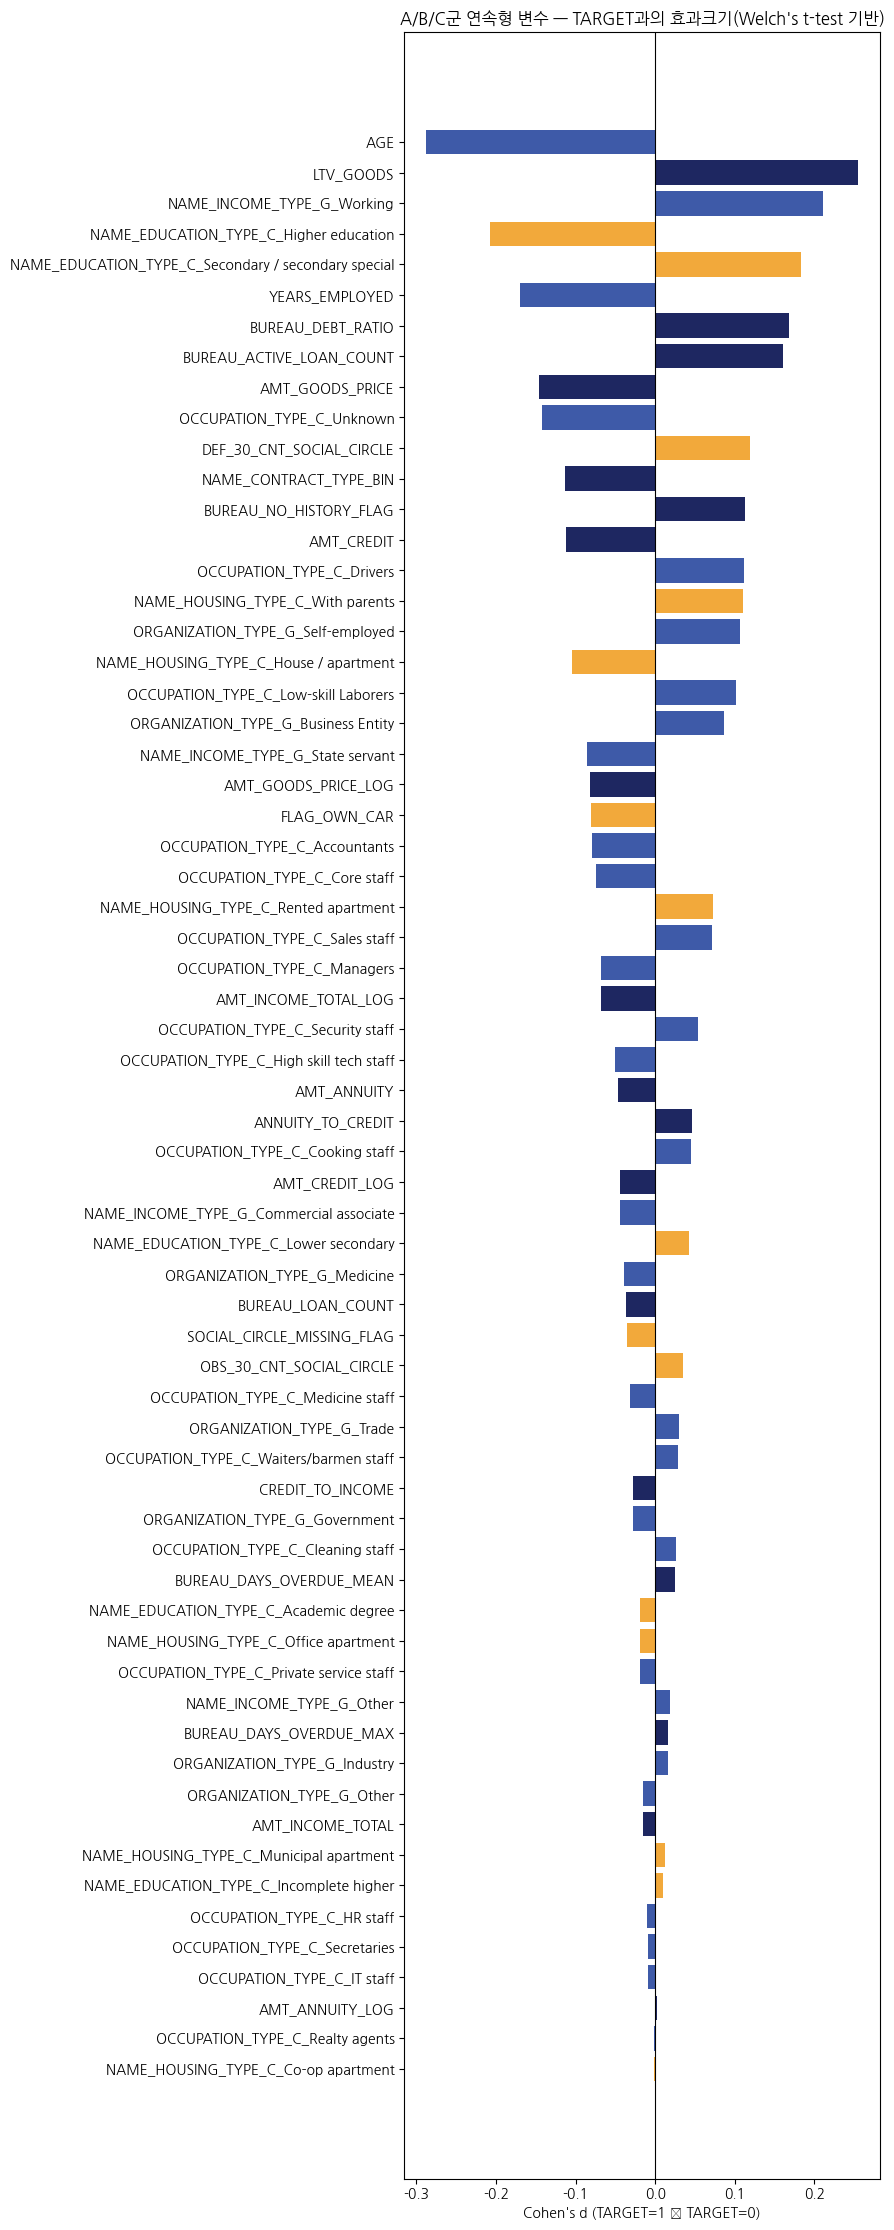

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, max(4, 0.35 * len(res_df))))
color_map = {"A_금융": "#1E2761", "B_기존비금융": "#3E5AA8", "C_신규비금융": "#F2A93B"}
colors = res_df["group"].map(color_map)
plt.barh(res_df["variable"][::-1], res_df["cohens_d"][::-1], color=colors[::-1])
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Cohen\'s d (TARGET=1 \u2212 TARGET=0)")
plt.title("A/B/C군 연속형 변수 — TARGET과의 효과크기(Welch\'s t-test 기반)")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "ttest_cohens_d_barplot.png"), dpi=150)
plt.show()